## Import Libraries

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,accuracy_score

import warnings
warnings.filterwarnings('ignore')


## Load Dataset

In [43]:
df = pd.read_csv('disease_prediction.csv',index_col=0)
df

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
patient_id,,,,,,,,,,,,,
1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,24,Male,105,237,86,86,30.9,69,Yes,Yes,Medium,No,No
997,40,Male,120,219,133,72,34.3,92,Yes,Yes,Medium,No,No
998,44,Female,114,273,114,74,36.0,76,No,No,Low,No,Yes


## Basic Data Exploration

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 1 to 1000
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1000 non-null   int64  
 1   gender               1000 non-null   object 
 2   glucose_mg_dl        1000 non-null   int64  
 3   cholesterol_mg_dl    1000 non-null   int64  
 4   systolic_bp          1000 non-null   int64  
 5   diastolic_bp         1000 non-null   int64  
 6   bmi                  1000 non-null   float64
 7   heart_rate           1000 non-null   int64  
 8   smoking              1000 non-null   object 
 9   alcohol_consumption  1000 non-null   object 
 10  physical_activity    1000 non-null   object 
 11  family_history       1000 non-null   object 
 12  disease              1000 non-null   object 
dtypes: float64(1), int64(6), object(6)
memory usage: 109.4+ KB


In [45]:
df.describe()

,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,51.190000,104.163000,210.014000,123.893000,81.032000,26.093000,75.968000
std,19.847514,25.076508,39.749111,18.701211,9.969974,4.758282,9.902982
min,18.000000,30.000000,89.000000,67.000000,49.000000,16.000000,47.000000
25%,33.000000,87.000000,183.000000,111.000000,74.000000,22.900000,70.000000
50%,52.500000,105.000000,210.500000,124.000000,81.000000,26.000000,76.000000
75%,69.000000,121.000000,235.250000,135.000000,88.000000,29.300000,83.000000
max,85.000000,184.000000,339.000000,195.000000,113.000000,41.500000,114.000000


In [46]:
df.describe(include=object)

,gender,smoking,alcohol_consumption,physical_activity,family_history,disease
count,1000,1000,1000,1000,1000,1000
unique,2,2,2,3,2,2
top,Female,Yes,Yes,Medium,No,Yes
freq,504,503,501,344,504,501


## Check Missing Values & Duplicate record

In [47]:
df.isna().sum()

age                    0
gender                 0
glucose_mg_dl          0
cholesterol_mg_dl      0
systolic_bp            0
diastolic_bp           0
bmi                    0
heart_rate             0
smoking                0
alcohol_consumption    0
physical_activity      0
family_history         0
disease                0
dtype: int64

In [48]:
df.duplicated().sum()

np.int64(0)

## Feature Encoding

In [49]:
cols = ["smoking", "alcohol_consumption", "family_history"]

df[cols] = df[cols].replace({"Yes": 1, "No": 0})

In [50]:
df["physical_activity"] = df["physical_activity"].map({"Low": 0,"Medium": 1,"High": 2})

In [51]:
df = pd.get_dummies(df, columns=["gender"], drop_first=True)

## Exploratory Data Analysis (EDA)

### Correlation Heatmap

<Axes: >

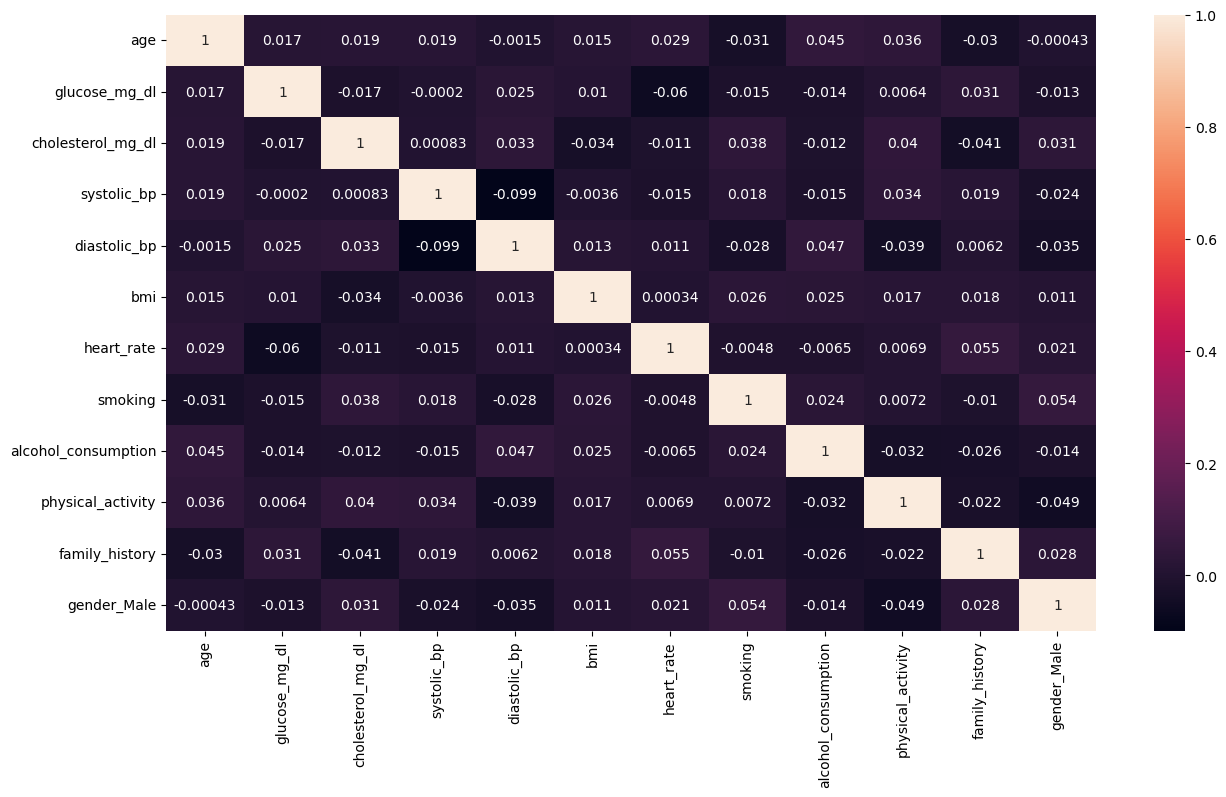

In [52]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)

### Outlier Detection

<Axes: >

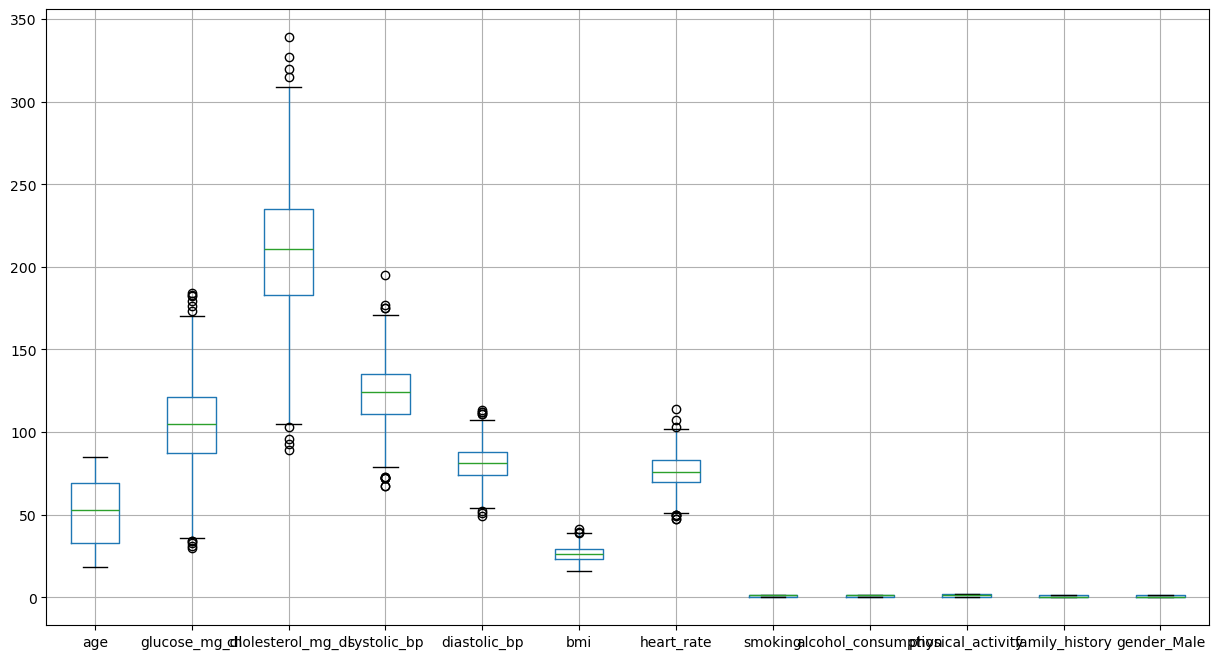

In [53]:
plt.figure(figsize=(15,8))
df.boxplot()

### Target Variable Analysis


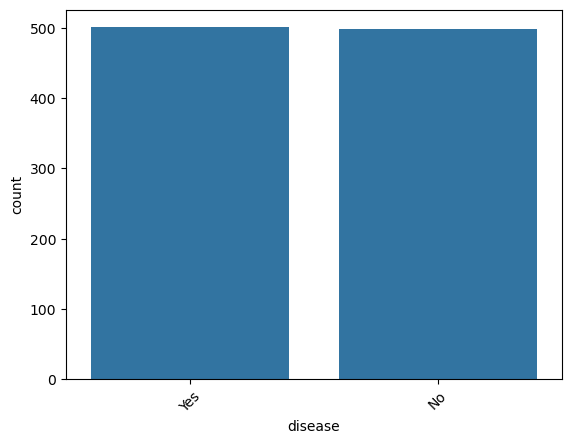

In [54]:
sns.countplot(x='disease', data=df)
plt.xticks(rotation=45)
plt.show()

### Feature Distribution Analysis

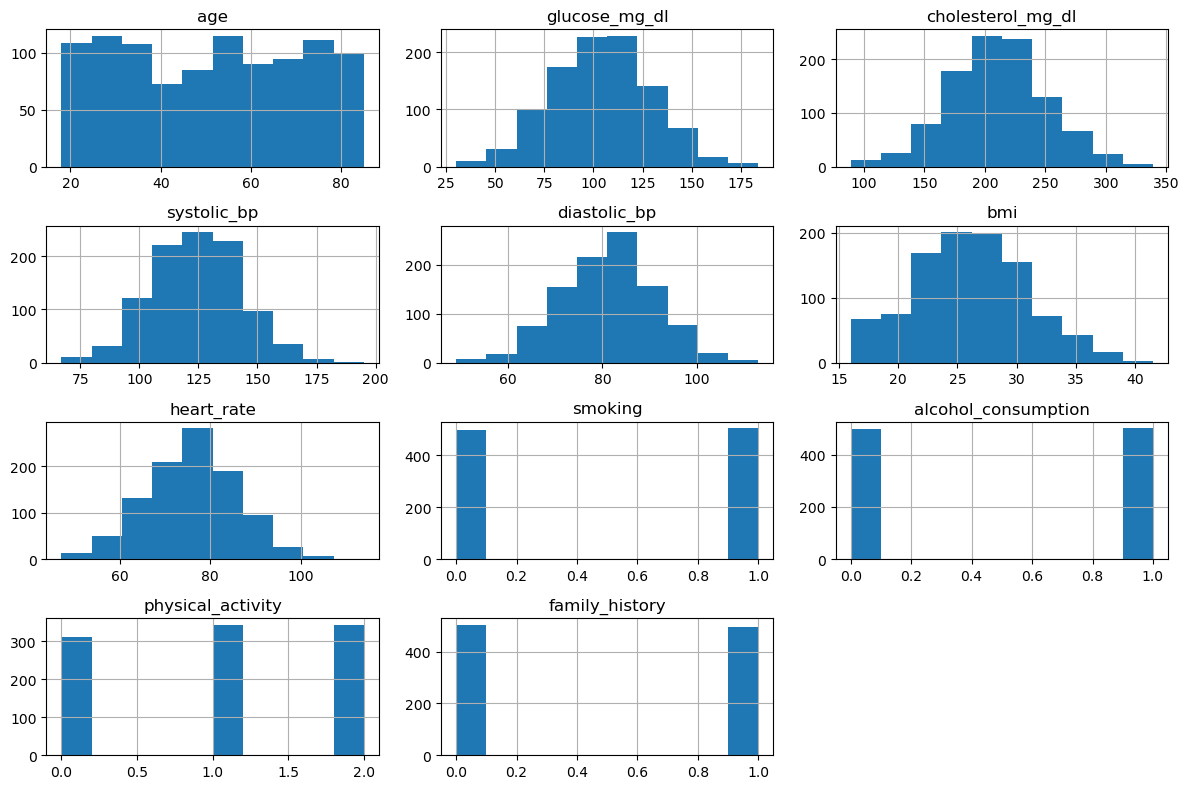

In [55]:

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

## Feature Selection

In [57]:
X = df.drop(columns="disease")
y = df["disease"]

In [66]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X,y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

cols = importance.sort_values(by="Importance",ascending=False).head(7)["Feature"].values

In [67]:
X = df[cols]
y = df["disease"]

##  Train-Test Split

In [68]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Model Building

In [69]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [70]:
ypred = model.predict(X_test)
ypred

array(['No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
       'No', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No',
       'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes',
       'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes',
       'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No',
       'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No',
       'No', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'No',
       'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'No', 'No',
       'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'No',
       'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No',
       'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes',
       'No', 'No', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes',
       'No', 'Yes', 'No', 'No', 'No', 'No', 'Yes', 'No', 'Yes',

In [74]:
accuracy_score(y_test,ypred)

0.81

In [71]:
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

          No       0.82      0.82      0.82       105
         Yes       0.80      0.80      0.80        95

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



In [73]:
model.score(X_train,y_train),model.score(X_test,y_test)

(1.0, 0.81)

##  Hyperparameter Tuning

In [118]:
params = {
    'max_depth' : [3,4,5,6],
    'min_samples_split' : [2,3,4,5],
    'n_estimators' : [60,65,70,75]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42),params,verbose=1)
grid.fit(X_train,y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [3, 4, 5, 6],
                         'min_samples_split': [2, 3, 4, 5],
                         'n_estimators': [60, 65, 70, 75]},
             verbose=1)

In [119]:
grid.best_params_

{'max_depth': 6, 'min_samples_split': 3, 'n_estimators': 70}

## Final Model Performance

In [136]:
model = RandomForestClassifier(random_state=42,max_depth=6,min_samples_split=3,n_estimators=70)
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=6, min_samples_split=3, n_estimators=70,
                       random_state=42)

In [137]:
ypred = model.predict(X_test)
ypred

array(['Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'Yes',
       'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes',
       'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes',
       'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No',
       'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No',
       'No', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'No',
       'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'No', 'Yes',
       'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'No',
       'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No',
       'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes',
       'No', 'Yes', 'No', 'No', 'No', 'No', 'Yes', 'No', 'Y

In [138]:
accuracy_score(y_test,ypred)

0.835

In [139]:
model.score(X_train,y_train),model.score(X_test,y_test)

(0.90375, 0.835)

## Conclusion

A Random Forest Classifier was developed to predict the presence of heart disease based on patient health attributes.

After data preprocessing, exploratory data analysis, feature selection, and model training, multiple model configurations were evaluated. The final model achieved:

- Training Accuracy: 90.38%
- Testing Accuracy: 83.50%

The model demonstrated good predictive performance and was able to generalize well to unseen data. Key factors influencing heart disease prediction included age, cholesterol levels, blood pressure, smoking habits, family history, and physical activity.

Overall, the Random Forest model proved to be an effective approach for heart disease prediction and can serve as a valuable tool for identifying individuals at higher risk, enabling early intervention and preventive healthcare measures.